# Day 08. Exercise 04
# Regression

## 0. Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [295]:
df = pd.read_csv('../data/checker_regression.csv').fillna(0)
df.drop_duplicates(inplace=True)
df.drop(columns='uid', inplace=True)
df.head()

,num_commits,pageviews,AVG(diff)
0,62,28.0,0.0
6,20,89.0,0.0
12,7,0.0,-2.0
13,86,0.0,-89.0
14,52,0.0,-48.5


In [296]:
y = df['AVG(diff)']
X = df.drop(columns='AVG(diff)')

In [297]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [299]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits)
    rmse_scores = []

    for train_index, test_index in kf.split(X):
        X_fold_train, X_fold_test = X.iloc[train_index], X.iloc[test_index]
        y_fold_train, y_fold_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_fold_train, y_fold_train)

        train_rmse = mean_squared_error(y_fold_train, model.predict(X_fold_train)) ** 0.5
        test_rmse  = mean_squared_error(y_fold_test,  model.predict(X_fold_test))  ** 0.5

        rmse_scores.append(test_rmse)
        print(f"train -  {train_rmse}   |   test -  {test_rmse}")

    avg = np.mean(rmse_scores)
    print(f"\nAverage RMSE on crossval is {avg}")

In [300]:
crossval(n_splits=10, X=X, y=y, model=LinearRegression())

train -  61.0609013662618   |   test -  63.829848149049276
train -  63.988158740733866   |   test -  20.035391040948966
train -  62.20348097704721   |   test -  51.23963921649241
train -  60.15245489851986   |   test -  68.19025234463642
train -  60.61932302839533   |   test -  65.92296908962915
train -  56.16434140855645   |   test -  95.44112210462167
train -  62.829271732704264   |   test -  42.535286141643965
train -  58.9639828974483   |   test -  88.68458481189293
train -  59.97579900754424   |   test -  72.7480702154982
train -  59.6927079308268   |   test -  78.6490932726747

Average RMSE on crossval is 64.72762563870876


In [301]:
crossval(n_splits=10, X=X, y=y, model=DecisionTreeRegressor(max_depth=1, random_state=21))

train -  49.05718513401479   |   test -  54.59186412993318
train -  51.53466278486121   |   test -  26.505276720125302
train -  48.785068959591456   |   test -  58.44823312628442
train -  51.435331199730236   |   test -  28.057524993588775
train -  49.7527364640082   |   test -  47.15711390582638
train -  44.92880454635694   |   test -  80.89271995629201
train -  48.489064922591645   |   test -  60.504902575552364
train -  50.531811061054455   |   test -  40.40602839813866
train -  49.06330813477833   |   test -  54.19047425516775
train -  49.10758151359317   |   test -  57.078508245359956

Average RMSE on crossval is 50.78326463062688


In [302]:
crossval(n_splits=10, X=X, y=y, model=RandomForestRegressor(max_depth=1, random_state=21))

train -  49.04327576098857   |   test -  54.39369674740781
train -  51.38601267325702   |   test -  26.746276605523448
train -  48.73252554387417   |   test -  58.61731300997749
train -  51.797109478439566   |   test -  36.7523404038624
train -  49.482636959231854   |   test -  48.74948604924087
train -  44.54721416515368   |   test -  83.02895693273447
train -  48.55313334488537   |   test -  58.39067217867046
train -  50.7070395210673   |   test -  45.25558242787537
train -  48.899383437116626   |   test -  55.528996588324326
train -  49.055031133341885   |   test -  59.78959653796965

Average RMSE on crossval is 52.725291748158625


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [303]:
lr_model = LinearRegression().fit(X_train, y_train)
dt_model = DecisionTreeRegressor(max_depth=4, random_state=21).fit(X_train, y_train)
rf_model = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=21).fit(X_train, y_train)

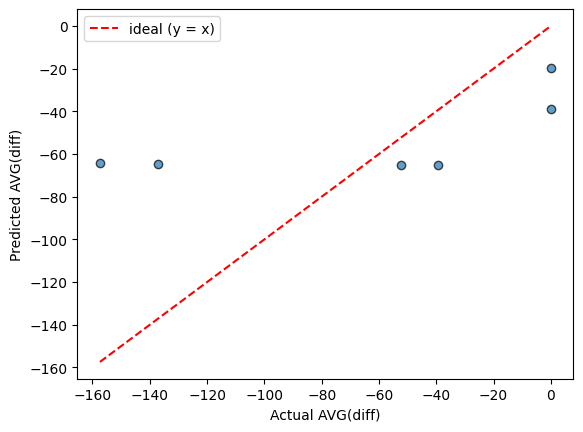

In [304]:
fig, ax = plt.subplots()
y_pred = lr_model.predict(X_test)

ax.scatter(y_test, lr_model.predict(X_test), alpha=0.7, edgecolors='k')

lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
       ]

ax.plot(lims, lims, 'r--', label='ideal (y = x)')

ax.set_xlabel('Actual AVG(diff)')
ax.set_ylabel('Predicted AVG(diff)')
ax.legend()

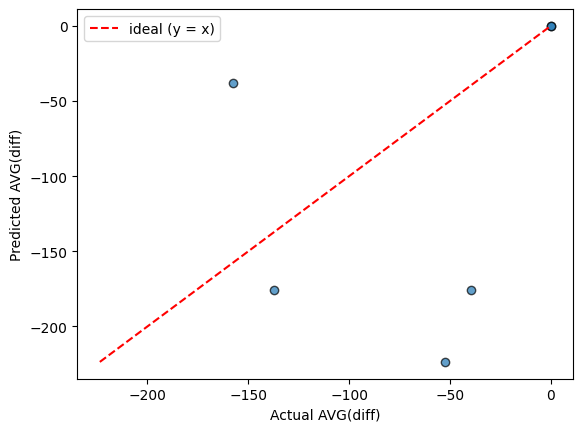

In [305]:
fig, ax = plt.subplots()
y_pred = dt_model.predict(X_test)

ax.scatter(y_test, dt_model.predict(X_test), alpha=0.7, edgecolors='k')

lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
       ]

ax.plot(lims, lims, 'r--', label='ideal (y = x)')

ax.set_xlabel('Actual AVG(diff)')
ax.set_ylabel('Predicted AVG(diff)')
ax.legend()

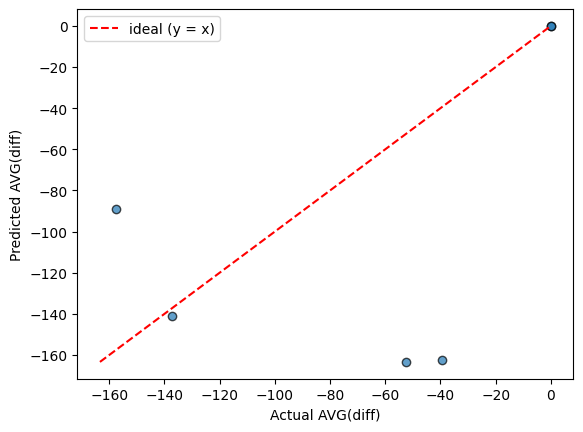

In [306]:
fig, ax = plt.subplots()
y_pred = rf_model.predict(X_test)

ax.scatter(y_test, rf_model.predict(X_test), alpha=0.7, edgecolors='k')

lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())
       ]

ax.plot(lims, lims, 'r--', label='ideal (y = x)')

ax.set_xlabel('Actual AVG(diff)')
ax.set_ylabel('Predicted AVG(diff)')
ax.legend()

Смотрел бы на диагональ, т.к если x совпадает с функцией, то это идеальный предикт